# Assignment - Anomaly Detection

## Phase 1: EDA & Hiểu Data

In [27]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf

# 1. Load Data
file_path = 'realKnownCause/ambient_temperature_system_failure.csv'

df = pd.read_csv(file_path)
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("--- Data Overview ---")
print(df.head())
print("\n--- Data Info ---")
print(df.info())


--- Data Overview ---
            timestamp      value
0 2013-07-04 00:00:00  69.880835
1 2013-07-04 01:00:00  71.220227
2 2013-07-04 02:00:00  70.877805
3 2013-07-04 03:00:00  68.959400
4 2013-07-04 04:00:00  69.283551

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  7267 non-null   datetime64[ns]
 1   value      7267 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 113.7 KB
None


In [28]:
# 2. Tính basic stats: mean, std, skewness (dùng scipy.stats.skew), min, max
mean_val = df['value'].mean()
std_val = df['value'].std()
skew_val = stats.skew(df['value'])
min_val = df['value'].min()
max_val = df['value'].max()

print("\nBasic Statistics")
print(f"Mean: {mean_val:.3f}")
print(f"Std: {std_val:.3f}")
print(f"Skewness: {skew_val:.3f}")
print(f"Min: {min_val:.3f}")
print(f"Max: {max_val:.3f}")


Basic Statistics
Mean: 71.242
Std: 4.248
Skewness: -0.393
Min: 57.458
Max: 86.223


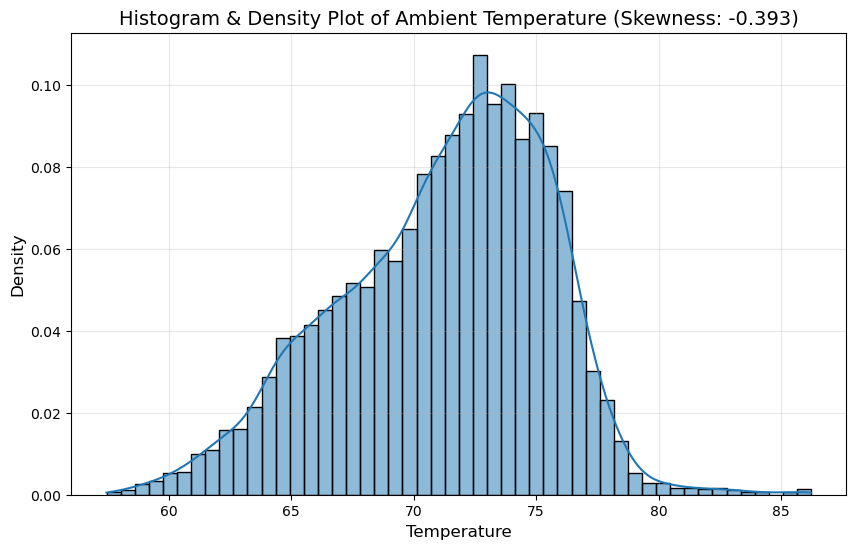

In [30]:
# 3. Plot histogram + density → data có Gaussian không? Skewed không? (dùng kiến thức section 1)
plt.figure(figsize=(10, 6))
sns.histplot(df['value'], kde=True, bins=50, stat="density")

plt.title(f'Histogram & Density Plot of Ambient Temperature (Skewness: {stats.skew(df['value']):.3f})', fontsize=14)
plt.xlabel("Temperature", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


Data gần tuân theo dạng Gaussian, nhưng không hoàn hảo 100% 
Data bị left Skewed và có skewed value = -0.393 (nằm trong khoảng từ -0.5 đến 0.5)


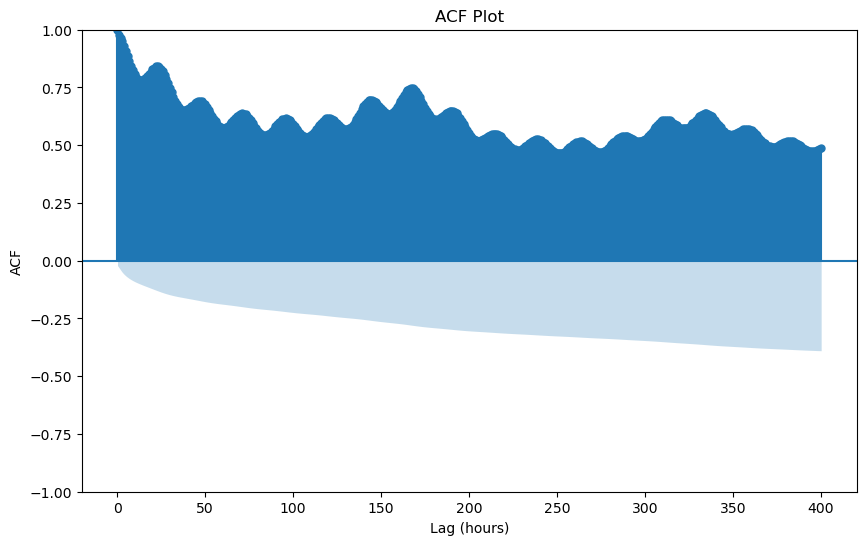

In [ ]:
# Plot ACF (statsmodels.graphics.tsaplots.plot_acf) → có seasonal không? Period bao nhiêu?
fig, ax = plt.subplots(figsize=(10, 6))

plot_acf(df['value'], lags=400, ax=ax)

plt.title('ACF Plot')
plt.xlabel('Lag (hours)')
plt.ylabel('ACF')

plt.show()

Biểu đồ ACF cho thấy data có seasonal do các đỉnh nhọn nhấp nhô có chu kỳ

Sau lag 0, đỉnh nhọn đầu tiên xuất hiện tại khoảng Lag 24-25. Các đỉnh tiếp theo xuất hiện tại khoảng Lag 48, 72, 96 nên Period của tập data là khoảng 24 giờ

Dữ liệu có tính Seasonal: Đồ thị ACF cho thấp các đỉnh nhọn tuần hoàn theo chu kỳ của dữ liệu là 24h 

Dùng STL Decomposition + 3σ là phù hợp cho bộ dữ liệu này

## Phase 2: Implement 2 Detectors
### Detector 1 — Statistical

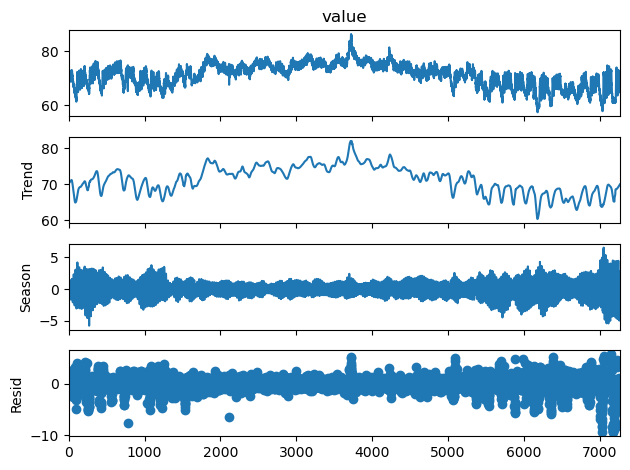

Tổng data: 7267
Số anomaly tìm thấy: 182


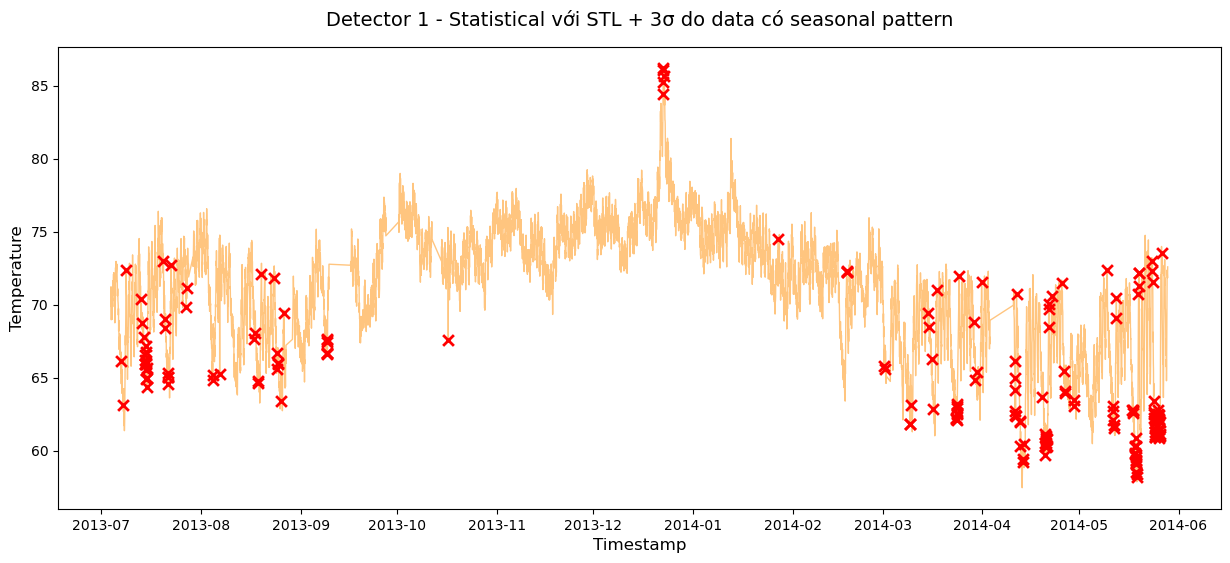

In [ ]:
from statsmodels.tsa.seasonal import STL

# STL Decomposition
stl = STL(df['value'], period=24, robust=True)
res = stl.fit()

# Lưu Residual vào DataFrame
df['residual'] = res.resid

# Đồ thị các components
res.plot()
plt.show()

residual = df['residual'].values
resid_mean = np.mean(residual)
resid_std = np.std(residual)

threshold = 3.0

# Tìm anomaly
df['is_anomaly_stl'] = np.abs(residual - resid_mean) > threshold * resid_std

# Tính toán upperlower bound
df['lower_bound'] = resid_mean - threshold * resid_std
df['upper_bound'] = resid_mean + threshold * resid_std

# Số anomaly tìm thấy
total_anomalies = df['is_anomaly_stl'].sum()
print(f"Tổng data: {len(df)}")
print(f"Số anomaly tìm thấy: {total_anomalies}")

# Visualize với anomaly
plt.figure(figsize=(15, 6))

plt.plot(df['timestamp'], df['value'], color='darkorange', alpha=0.5, linewidth=1, label='Nhiệt độ thực tế')

# Lọc các anomaly trên biểu đồ
anomalies_df = df[df['is_anomaly_stl'] == True]
plt.scatter(anomalies_df['timestamp'], anomalies_df['value'], 
            color='red', marker='x', s=60, linewidths=2, label='Anomaly phát hiện', zorder=5)

# Label các cột và tittle
plt.title("Detector 1 - Statistical với STL + 3σ do data có seasonal pattern", fontsize=14, pad=15)
plt.xlabel("Timestamp", fontsize=12)
plt.ylabel("Temperature", fontsize=12)
plt.show()


### Detector 2 - ML: Isolation Forest

In [60]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score

#  Biến 1 time series thành feature table cho Isolation Forest
s = pd.Series(df['value'])

window_day = 24 

df_features = pd.DataFrame({
    'timestamp': df['timestamp'],
    'value': s,
    'rolling_mean_day': s.rolling(window_day).mean(), 
    'rolling_std_day': s.rolling(window_day).std(), 
    'rate_of_change': s.diff(),
    'rate_of_change_6h': s.diff(6), 
    'lag_1': s.shift(1),
    'lag_24': s.shift(window_day), 
})

# Loại row có NaN do shift ở đầu 
df_features = df_features.dropna().reset_index(drop=True)

X = df_features[['value', 'rolling_mean_day', 'rolling_std_day', 
                 'rate_of_change', 'rate_of_change_6h', 'lag_1', 'lag_24']]


# Train Isolation Forest + Tune contamination parameter: thử 0.01, 0.02, 0.05 → ghi lại precision/recall mỗi giá trị
y_true = df['is_anomaly_stl'].iloc[24:].astype(int).values

contamination_list = [0.01, 0.02, 0.05]
results_summary = []


for contam in contamination_list:
    clf = IsolationForest(
        n_estimators=200,  
        contamination=contam, 
        max_features=1.0, 
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X)
    
    # Dự đoán labels (-1: Anomaly, 1: Normal)
    preds = clf.predict(X)
    
    # Chuyển về dạng 0-1 để khớp với df['is_anomaly_stl']
    y_pred = np.where(preds == -1, 1, 0)
    
    # Tính toán Precision và Recall
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    
    # Lưu kết quả
    results_summary.append({
        'Contamination': contam,
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'Detected Anomalies': np.sum(y_pred)
    })
    
    print(f"\nContamination = {contam}")
    print(f"- Số anomaly phát hiện: {np.sum(y_pred)}")
    print(f"- Precision: {precision:.4f}")
    print(f"- Recall:    {recall:.4f}")


Contamination = 0.01
- Số anomaly phát hiện: 73
- Precision: 0.1370
- Recall:    0.0549

Contamination = 0.02
- Số anomaly phát hiện: 145
- Precision: 0.1241
- Recall:    0.0989

Contamination = 0.05
- Số anomaly phát hiện: 363
- Precision: 0.1956
- Recall:    0.3901


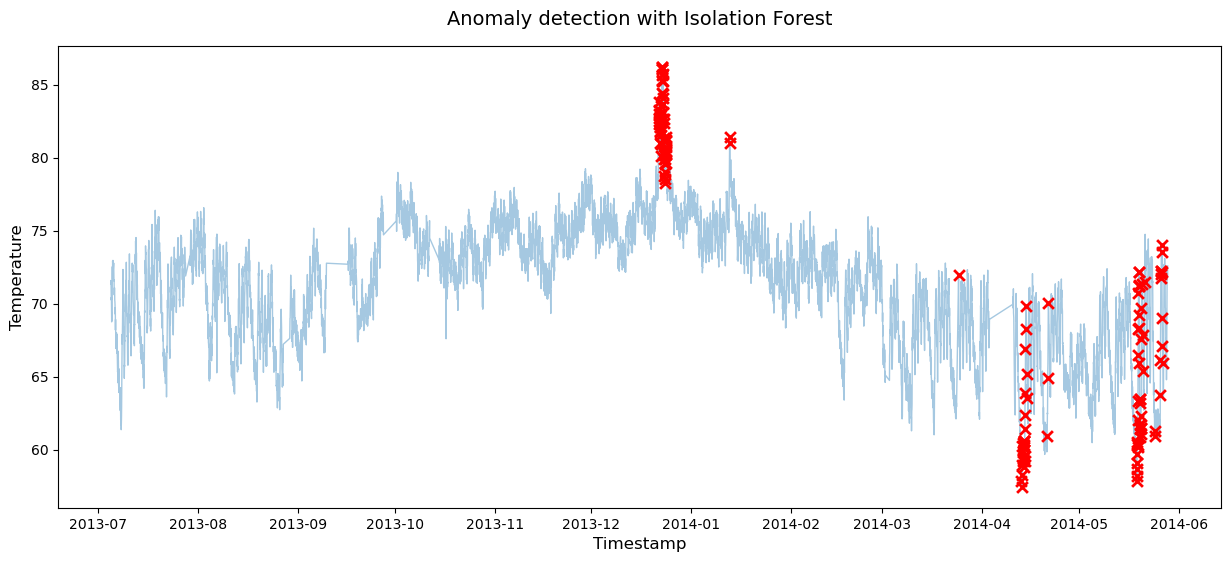

In [62]:
# Plot kết quả anomaly detection detector 2
plot_contam = 0.02

clf_plot = IsolationForest(
    n_estimators=200,  
    contamination=plot_contam, 
    max_features=1.0, 
    random_state=42,
    n_jobs=-1
)
clf_plot.fit(X)

preds_plot = clf_plot.predict(X)
df_features['is_anomaly_iforest'] = np.where(preds_plot == -1, 1, 0)

plt.figure(figsize=(15, 6))


plt.plot(df_features['timestamp'], df_features['value'], 
         color='tab:blue', alpha=0.4, linewidth=1, label='Nhiệt độ thực tế')

# Lọc ra các nhãn anomaly
anomalies_iforest = df_features[df_features['is_anomaly_iforest'] == 1]

# Tìm anomaly trên biểu đồ
plt.scatter(anomalies_iforest['timestamp'], anomalies_iforest['value'], 
            color='red', marker='x', s=60, linewidths=2, label='Anomaly (Isolation Forest)', zorder=5)


plt.title(f"Anomaly detection with Isolation Forest", fontsize=14, pad=15)
plt.xlabel("Timestamp", fontsize=12)
plt.ylabel("Temperature", fontsize=12)

plt.show()